# Digital Signal Processing Training Program 

![Texto Alternativo](images/V-CC_Color_Completa_TextoAzul.png)

### Dev by:
-   Elmer Pimentel Farias


# *Sampling Rate Conversion*

 ###  1. Theoretical Introduction 

In modern Digital Signal Processing (DSP) applications, it is common to need different sampling rates to coexist within the same system. Multirate systems arise from the need to make these different rates compatible, and they perform this conversion fundamentally through two operations: decimation and interpolation.

- #### Decimation

    Downsampling by an integer factor $M$ consists of reducing the sampling rate of a discrete signal by keeping only one out of every $M$ original samples. Mathematically, the decimated signal $x_d[n]$ in the time domain is expressed as:$$x_d[n] = x[nM], \quad M \in \mathbb{Z}^+$$In the normalized frequency domain, decimation causes a spectral expansion, given by the relationship:$$X_d(\hat{f}) = \frac{1}{M}\sum_{q=0}^{M-1}X\left(\frac{\hat{f}-q}{M}\right)$$To avoid the phenomenon of aliasing (spectral overlap), decimation must be preceded by a low-pass filter (anti-aliasing) whose cutoff frequency $f_c$ obeys the criterion:$$f_c \le \frac{f_s}{2M}$$ 

- #### Interpolation

 Upsampling by a factor $L$ consists of increasing the sampling rate by inserting $L-1$ zeros between the samples of the original signal.The interpolated signal $x_i[n]$ is modeled as:$$x_i[n] = \begin{cases} x[n/L], & \text{if } n \text{ is a multiple of } L \\ 0, & \text{otherwise} \end{cases}$$This operation causes a spectral compression and the emergence of unwanted spectral copies (images) at multiples of $1/L$. Therefore, interpolation must be followed by a low-pass filter (anti-imaging) with a normalized cutoff frequency limiting the band to:$$\hat{f}_c \le \frac{1}{2L}$$

- ### To make these operations viable for long or real-time signals with computational efficiency, linear filtering is used operating in the frequency domain via the Fast Fourier Transform (FFT and IFFT), often combined with block processing algorithms, such as the overlap-and-save method.

 ### 2. Project Objectives:

 This practical report focuses on exploring and analyzing the behavior of multirate systems. The specific objectives include:
 - Implement linear filtering operations: Perform the decimation and interpolation of signals in the frequency domain, using algorithms based on FFT/IFFT combined with the overlap-and-save method for efficient processing.
 - Evaluate conversion distortions: Investigate and measure the distortions (such as aliasing and spectral imaging) introduced by the interpolation and decimation processes in previously band-limited signals.
 - Analyze spectral behavior: Observe, compare, and document the frequency spectrum of the signals before and after the interpolation and decimation operations, systematically varying the rate conversion factors ($M$ and $L$).

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin
from fractions import Fraction


![Texto Alternativo](images/Up&Down.png)


In [6]:
def upsample_fft_ideal(x, L):
    """
    Performs spectral zero-padding by inserting zeros at high frequencies 
    to upsample the input signal.
    
    Args:
        x (array-like): The input signal in the time domain.
        L (int): The upsampling factor.
        
    Returns:
        numpy.ndarray: The upsampled time-domain signal.
    """
    # Step 1 & 2: Get the length of the input and calculate the new output length
    N_in = len(x)
    N_out = N_in * L
    
    # Step 3: Compute the Fast Fourier Transform (FFT) of the input signal
    X = np.fft.fft(x)
    
    # Step 4: Shift the zero-frequency (DC) component to the center of the spectrum
    X_c = np.fft.fftshift(X)
    
    # Step 5: Initialize a new zero-filled array for the expanded spectrum (ZeroVector)
    Y_c = np.zeros(N_out, dtype=complex)
    
    # Step 6: Place the original centered spectrum into the middle of the new zero-padded array.
    # This effectively pads the high-frequency components with zeros (ideal low-pass filtering).
    start = (N_out - N_in) // 2
    end = start + N_in
    Y_c[start:end] = X_c
    
    # Step 7: Inverse shift to move the DC component back to the edges
    Y = np.fft.ifftshift(Y_c)
    
    # Step 8: Compute the Inverse Fast Fourier Transform (IFFT) to return to the time domain.
    # np.real() ensures any residual imaginary parts from numerical imprecision are discarded.
    y = np.real(np.fft.ifft(Y))
    
    # Amplitude Compensation: Spreading the signal's energy across more bins 
    # reduces its time-domain amplitude. Multiplying by L restores the original amplitude.
    return y * L

In [7]:

def decimate_fft_ideal(x, M):
    """
    Performs ideal low-pass filtering by removing high-frequency bins 
    to downsample (decimate) the input signal.
    
    Args:
        x (array-like): The input signal in the time domain.
        M (int): The decimation factor.
        
    Returns:
        numpy.ndarray: The decimated time-domain signal.
    """
    # Step 1 & 2: Get the length of the input and calculate the new output length
    N_in = len(x)
    N_out = N_in // M 
    
    # Step 3: Compute the Fast Fourier Transform (FFT) of the input signal
    X = np.fft.fft(x)
    
    # Step 4: Shift the zero-frequency (DC) component to the center of the spectrum
    X_c = np.fft.fftshift(X)
    
    # Step 5: KeepCentralBins (Keep only the center of the spectrum)
    # This acts as an ideal low-pass filter, discarding high frequencies to avoid aliasing.
    start = (N_in - N_out) // 2
    end = start + N_out
    X_bb = X_c[start:end]
    
    # Step 6: Inverse shift to move the DC component back to the edges
    X_out = np.fft.ifftshift(X_bb)
    
    # Step 7: Compute the Inverse Fast Fourier Transform (IFFT) to return to the time domain
    y = np.real(np.fft.ifft(X_out))
    
    # Amplitude Compensation: The native IFFT function divides by the new length (N_out), 
    # but the original signal's spectral energy was based on N_in. 
    # We must compensate by dividing by the decimation factor M.
    return y / M

## Overlap-and-Save Method

![Texto Alternativo](images/OVS.png)


In [ ]:
def OVS_RateConverter(x, r, block_size=2048, overlap=None):
    """
    Resamples the signal using ideal FFT and the Overlap-and-Save method
    to support long signals without causing memory overflow.
    
    Args:
        x (array-like): The input signal in the time domain.
        r (float): The resampling ratio (r > 0).
        block_size (int): Size of the processing chunks.
        overlap (int): Number of overlapping samples to absorb edge artifacts.
        
    Returns:
        numpy.ndarray: The resampled time-domain signal.
    """
    # Find coprime integers (L, M) such that r = L/M [cite: 103]
    frac = Fraction(r).limit_denominator()
    L = frac.numerator
    M = frac.denominator
    
    print(f"[*] Factor r={r} -> L={L}, M={M} (Block processing)")
    
    # 1. Overlap-and-Save Configuration
    if overlap is None:
        overlap = block_size // 4
        
    # Ensures that sizes are exact multiples to avoid indexing errors
    # during the upsampling/decimation steps
    overlap = int(np.ceil(overlap / (2 * M)) * (2 * M))
    block_size = int(np.ceil(block_size / M) * M)
    
    # Calculate the step sizes for advancing through the input and output
    step_in = block_size - overlap
    step_out = (step_in * L) // M
    
    half_overlap_in = overlap // 2
    half_overlap_out = (overlap * L) // M // 2
    
    # 2. Symmetric padding at the edges of the input signal
    # This ensures the very beginning and end of the signal aren't lost as "edge artifacts"
    x_padded = np.pad(x, (half_overlap_in, half_overlap_in), mode='constant')
    N_padded = len(x_padded)
    
    y_out_blocks = []
    
    # 3. Main processing loop
    for i in range(0, N_padded - overlap, step_in):
        chunk = x_padded[i : i + block_size]
        
        # Zero-pad the last chunk if it's smaller than the block_size
        if len(chunk) < block_size:
            chunk = np.pad(chunk, (0, block_size - len(chunk)), mode='constant')
            
        # --- ORIGINAL CORE LOGIC BEGINS HERE ---
        # Apply upsampling if L > 1 [cite: 104-108]
        if L > 1:
            chunk_L = upsample_fft_ideal(chunk, L)
        else:
            chunk_L = chunk
            
        # Apply decimation if M > 1 [cite: 110-115]
        if M > 1:
            chunk_resampled = decimate_fft_ideal(chunk_L, M)
        else:
            chunk_resampled = chunk_L
        # --- ORIGINAL CORE LOGIC ENDS HERE ---
        
        # Discard the edges (FFT boundary effects) and save the valid center portion
        valid_chunk = chunk_resampled[half_overlap_out : half_overlap_out + step_out]
        y_out_blocks.append(valid_chunk)
        
    # 4. Final reconstruction
    # Concatenate all valid blocks back into a single array
    y_final = np.concatenate(y_out_blocks)
    expected_len = (len(x) * L) // M
    
    # Trim any excess padded samples to return the exact expected length
    return y_final[:expected_len]

[*] Fator r=1.5 -> L=3, M=2 (Processamento em blocos)


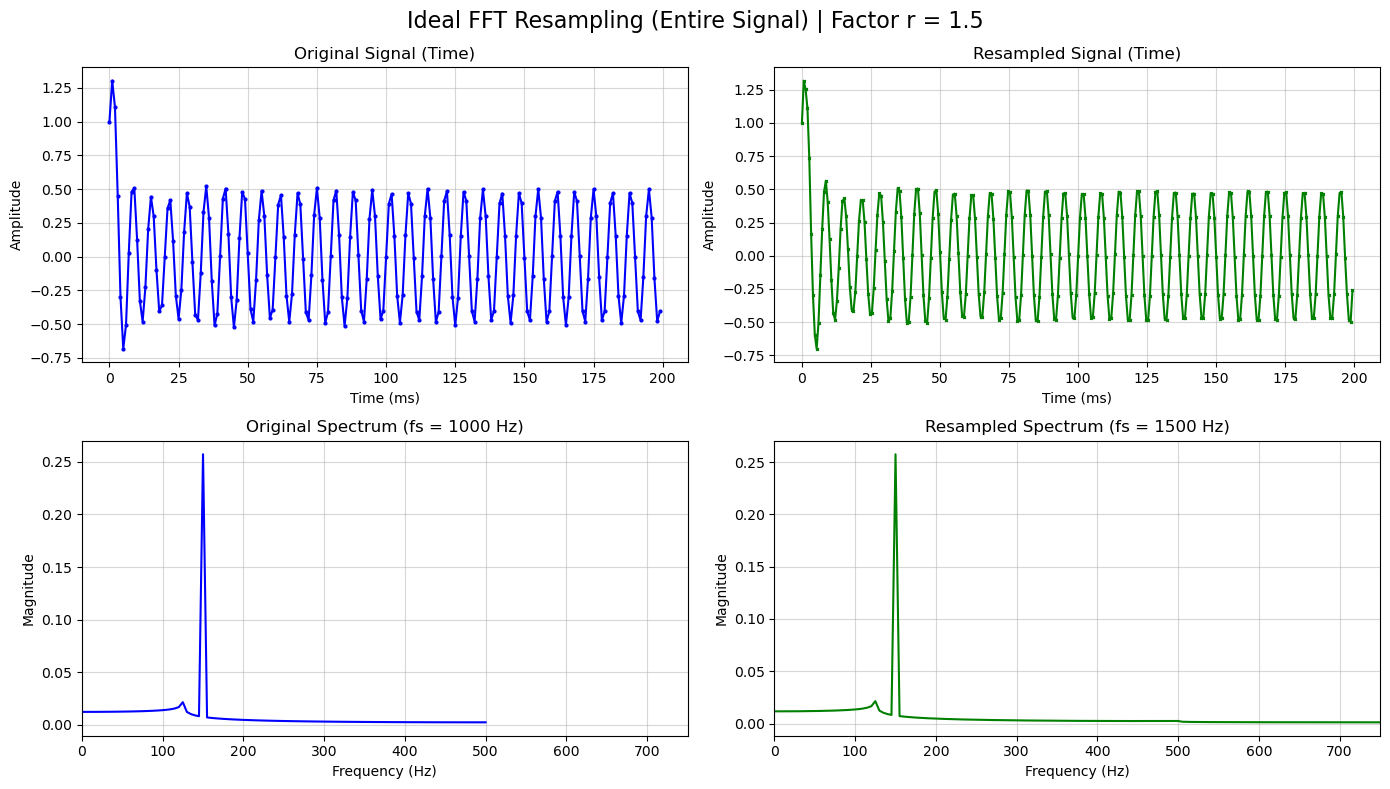

In [41]:
# 1. Test Signal Configuration
fs_in = 1000                  # Original sampling rate (
r = 1.5                       # Resampling factor (L=3, M=2)
fs_out = int(fs_in * r)       # New sampling rate (72 kHz)
duration = 0.2                # S

# Original time axis
#t_in = np.arange(0, 1.0, 1/fs_in)
t_in = np.arange(int(fs_in * duration)) / fs_in

# Creating the signal: A sum of two frequencies (40 Hz and 150 Hz)
freq1, freq2 = 40.0, 150.0
x_original = np.sinc(2 * np.pi * freq1 * t_in) + 0.5 * np.sin(2 * np.pi * freq2 * t_in)

# Resampling the signal via FFT-based ideal resampling with Overlap-and-Save
y_resampled = OVS_RateConverter(x_original, r)

# Resampled time axis
t_out = np.arange(len(y_resampled)) / fs_out

# Calculating Frequency Spectra (Real FFT)
X_fft = np.fft.rfft(x_original)
f_in = np.fft.rfftfreq(len(x_original), 1/fs_in)
magnitude_X = np.abs(X_fft) / len(x_original) # Normalizing amplitude

Y_fft = np.fft.rfft(y_resampled)
f_out = np.fft.rfftfreq(len(y_resampled), 1/fs_out)
magnitude_Y = np.abs(Y_fft) / len(y_resampled) # Normalizing amplitude

fig, axs = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(f'Ideal FFT Resampling (Entire Signal) | Factor r = {r}', fontsize=16)

# Original Signal in Time
axs[0, 0].plot(t_in * 1000, x_original, color='blue', marker='o', markersize=2, linestyle='-')
axs[0, 0].set_title('Original Signal (Time)')
axs[0, 0].set_xlabel('Time (ms)')
axs[0, 0].set_ylabel('Amplitude')
axs[0, 0].grid(True, alpha=0.5)

# Resampled Signal in Time
axs[0, 1].plot(t_out * 1000, y_resampled, color='green', marker='x', markersize=2, linestyle='-')
axs[0, 1].set_title('Resampled Signal (Time)')
axs[0, 1].set_xlabel('Time (ms)')
axs[0, 1].set_ylabel('Amplitude')
axs[0, 1].grid(True, alpha=0.5)

# Original Signal Spectrum
axs[1, 0].plot(f_in, magnitude_X, color='blue')
axs[1, 0].set_title(f'Original Spectrum (fs = {fs_in} Hz)')
axs[1, 0].set_xlabel('Frequency (Hz)')
axs[1, 0].set_ylabel('Magnitude')
axs[1, 0].set_xlim(0, fs_out / 2) 
axs[1, 0].grid(True, alpha=0.5)

#  Resampled Signal Spectrum
axs[1, 1].plot(f_out, magnitude_Y, color='green')
axs[1, 1].set_title(f'Resampled Spectrum (fs = {fs_out} Hz)')
axs[1, 1].set_xlabel('Frequency (Hz)')
axs[1, 1].set_ylabel('Magnitude')
axs[1, 1].set_xlim(0, fs_out / 2) 
axs[1, 1].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

[*] Fator r=0.5 -> L=1, M=2 (Processamento em blocos)


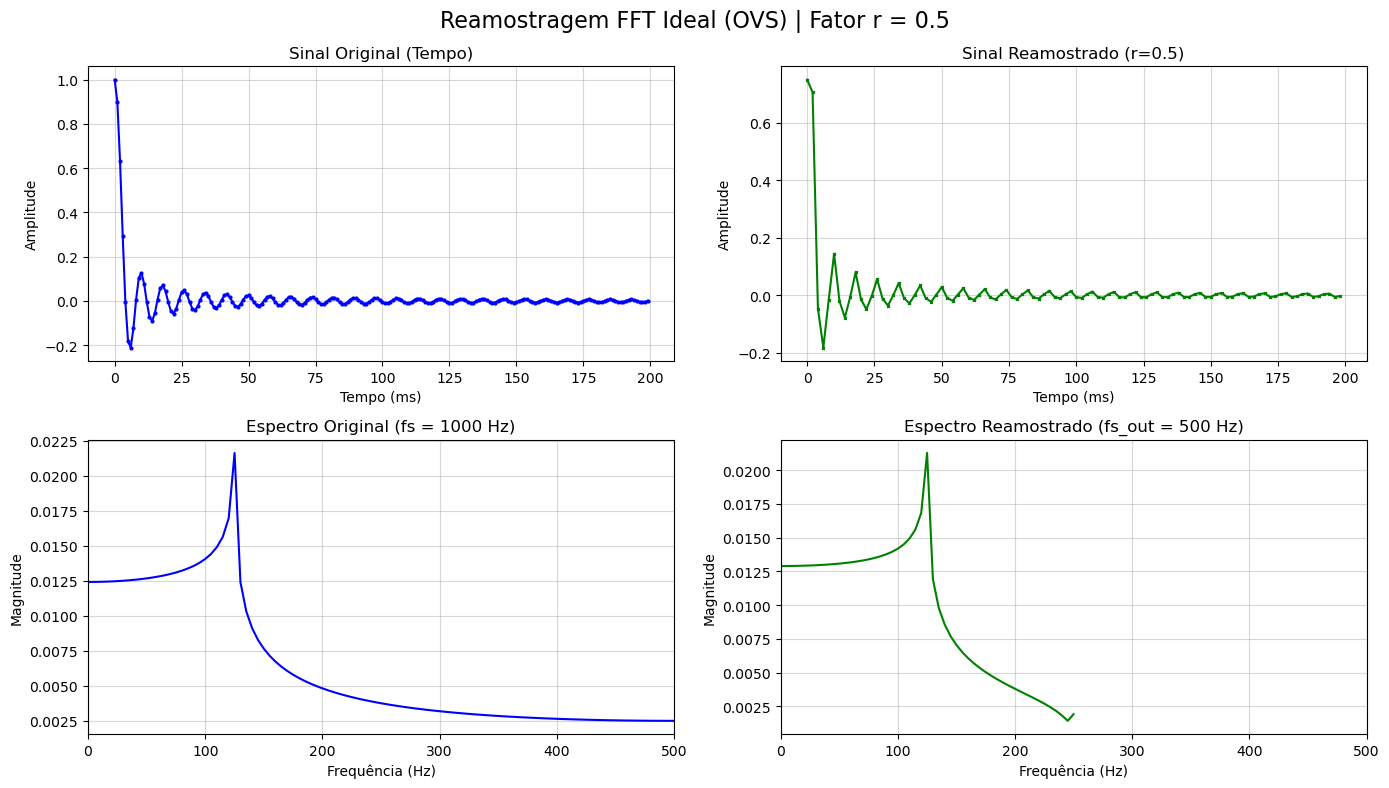

[*] Fator r=0.8 -> L=4, M=5 (Processamento em blocos)


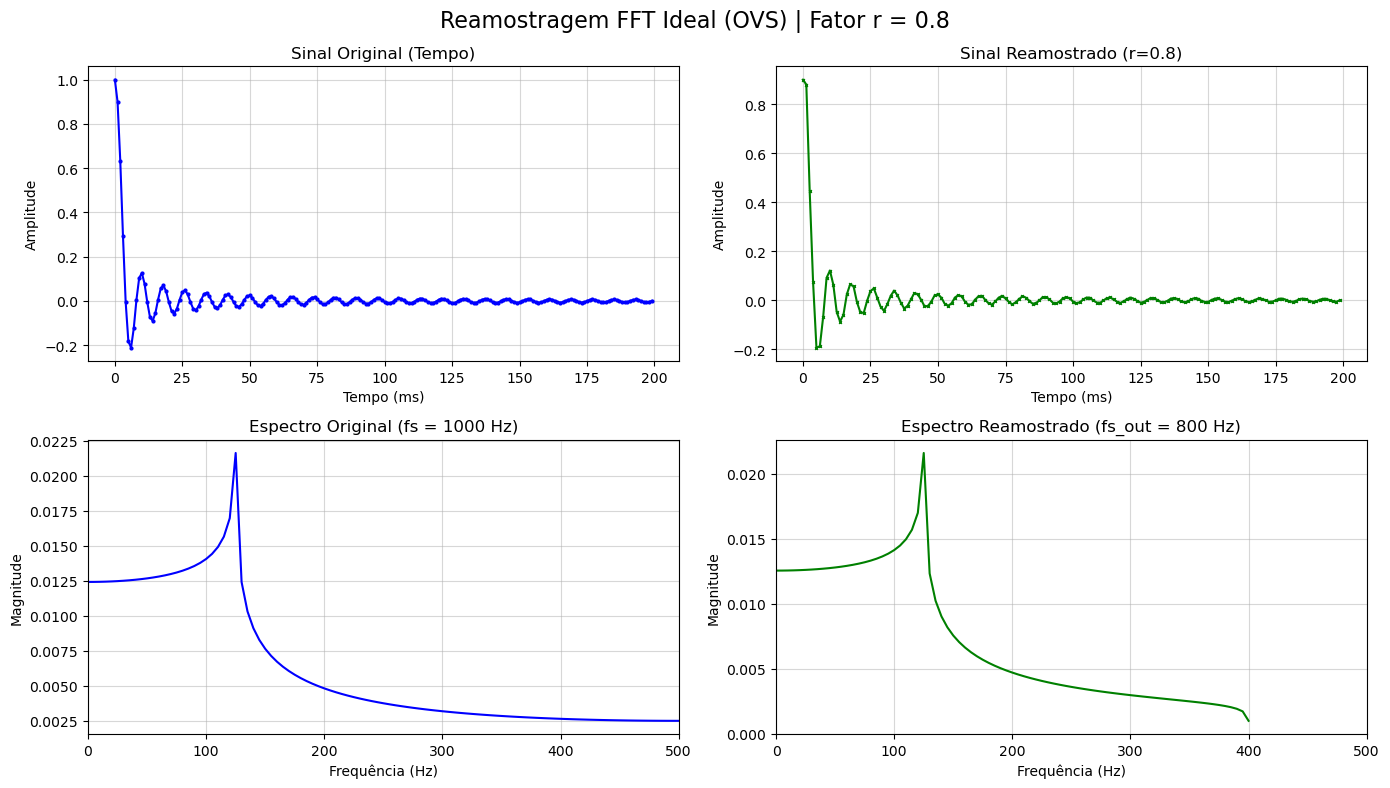

[*] Fator r=1.5 -> L=3, M=2 (Processamento em blocos)


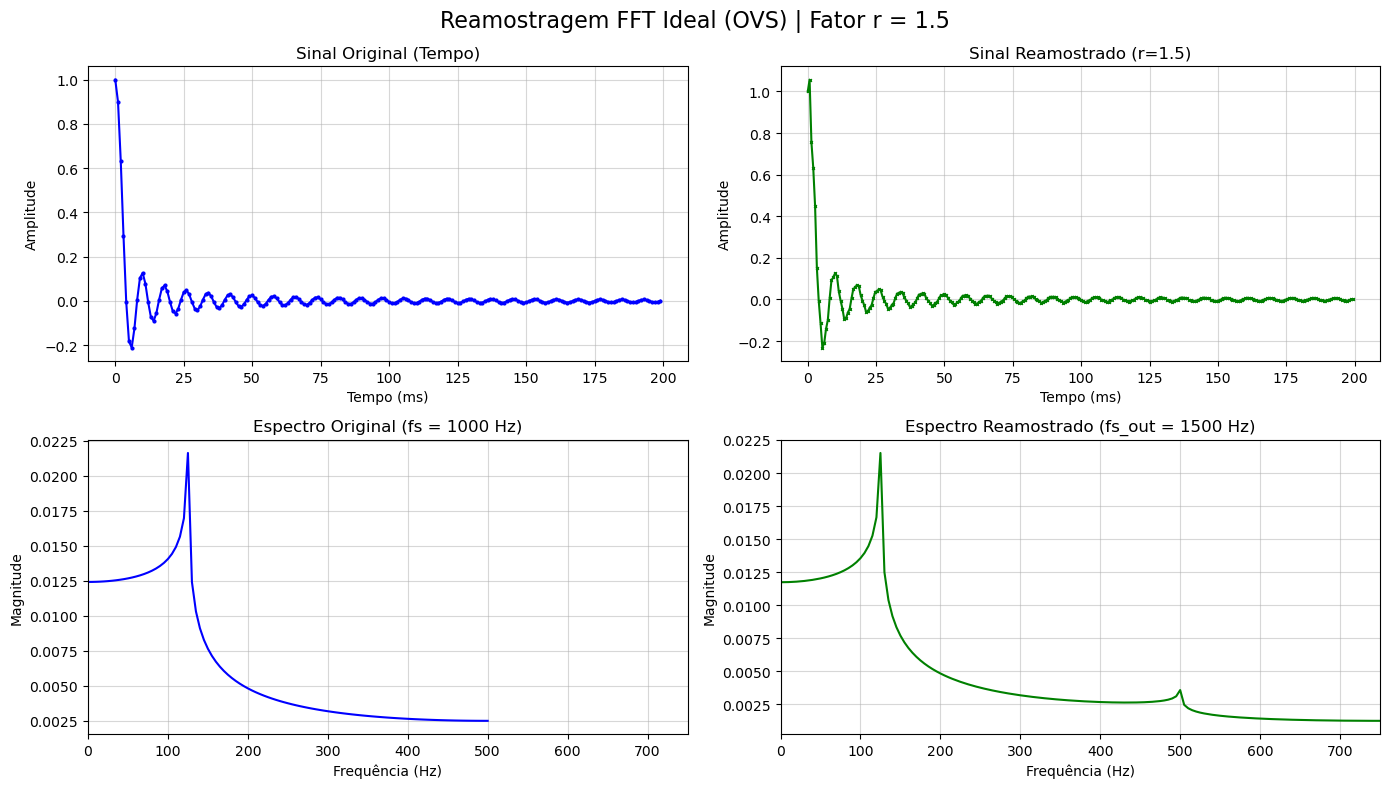

[*] Fator r=2.0 -> L=2, M=1 (Processamento em blocos)


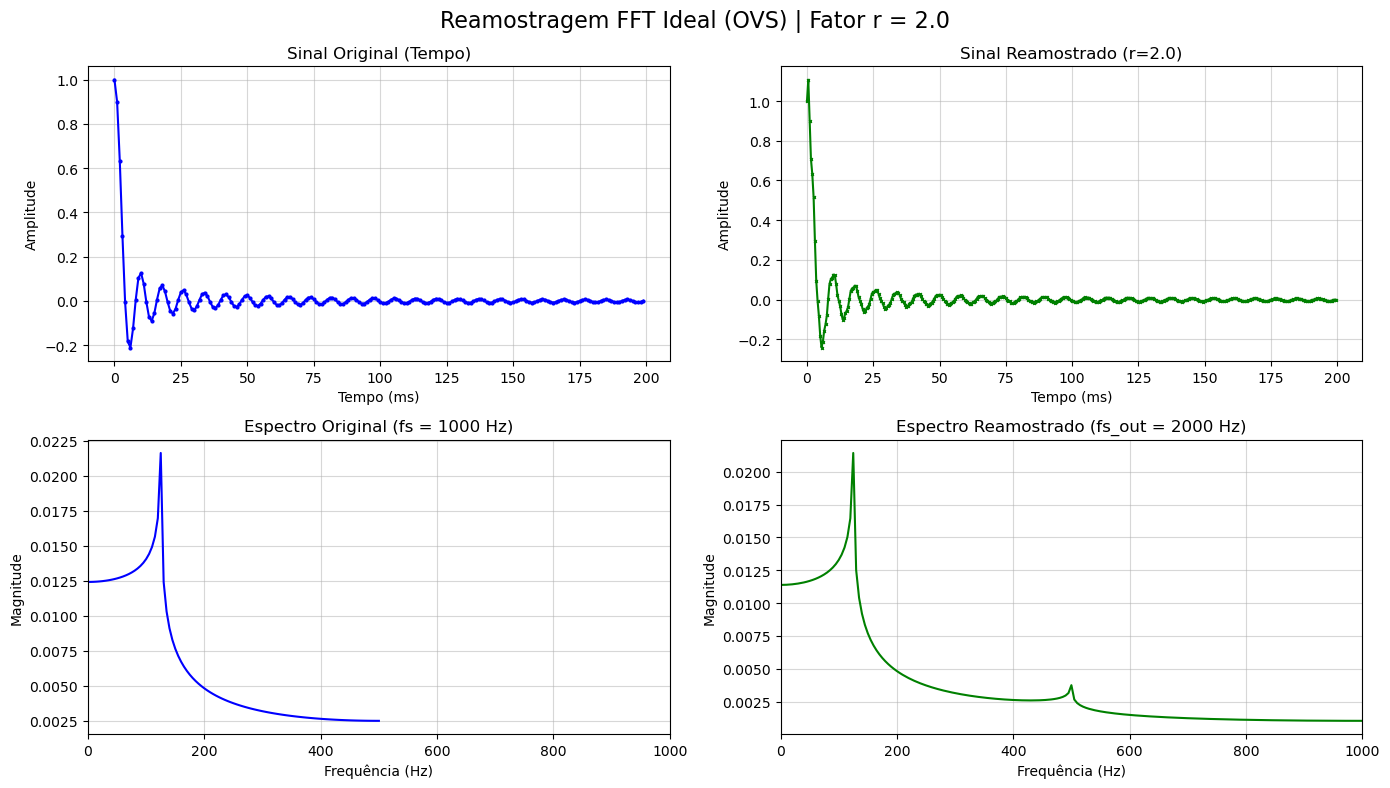

In [43]:
# Fatores solicitados
fatores_r = [0.5, 0.8, 1.5, 2.0]

# Configurações base
fs_in = 1000
duration = 0.2
t_in = np.arange(int(fs_in * duration)) / fs_in
freq1, freq2 = 40.0, 150.0
x_original = np.sinc(2 * np.pi * freq1 * t_in) #+ 0.5 * np.sin(2 * np.pi * freq2 * t_in)

for r in fatores_r:
    fs_out = int(fs_in * r)
    
    # Executa a sua função original
    y_resampled = OVS_RateConverter(x_original, r)
    
    t_out = np.arange(len(y_resampled)) / fs_out

    # Cálculos de Espectro
    X_fft = np.fft.rfft(x_original)
    f_in = np.fft.rfftfreq(len(x_original), 1/fs_in)
    magnitude_X = np.abs(X_fft) / len(x_original)

    Y_fft = np.fft.rfft(y_resampled)
    f_out = np.fft.rfftfreq(len(y_resampled), 1/fs_out)
    magnitude_Y = np.abs(Y_fft) / len(y_resampled)

    # Plotagem
    fig, axs = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f'Reamostragem FFT Ideal (OVS) | Fator r = {r}', fontsize=16)

    # Tempo - Original
    axs[0, 0].plot(t_in * 1000, x_original, color='blue', marker='o', markersize=2, linestyle='-')
    axs[0, 0].set_title('Sinal Original (Tempo)')
    axs[0, 0].set_xlabel('Tempo (ms)')
    axs[0, 0].set_ylabel('Amplitude')
    axs[0, 0].grid(True, alpha=0.5)

    # Tempo - Reamostrado
    axs[0, 1].plot(t_out * 1000, y_resampled, color='green', marker='x', markersize=2, linestyle='-')
    axs[0, 1].set_title(f'Sinal Reamostrado (r={r})')
    axs[0, 1].set_xlabel('Tempo (ms)')
    axs[0, 1].set_ylabel('Amplitude')
    axs[0, 1].grid(True, alpha=0.5)

    # Espectro - Original
    axs[1, 0].plot(f_in, magnitude_X, color='blue')
    axs[1, 0].set_title(f'Espectro Original (fs = {fs_in} Hz)')
    axs[1, 0].set_xlabel('Frequência (Hz)')
    axs[1, 0].set_ylabel('Magnitude')
    axs[1, 0].set_xlim(0, max(fs_in, fs_out) / 2)
    axs[1, 0].grid(True, alpha=0.5)

    # Espectro - Reamostrado
    axs[1, 1].plot(f_out, magnitude_Y, color='green')
    axs[1, 1].set_title(f'Espectro Reamostrado (fs_out = {fs_out} Hz)')
    axs[1, 1].set_xlabel('Frequência (Hz)')
    axs[1, 1].set_ylabel('Magnitude')
    axs[1, 1].set_xlim(0, max(fs_in, fs_out) / 2)
    axs[1, 1].grid(True, alpha=0.5)

    plt.tight_layout()
    plt.show()

#### Interpolação e Decimação no Tempo

![Texto Alternativo](images/DIT.png)


In [16]:


def decimate_diagram_ovs(x, h, M, N_fft):
    """
    Decimação via FFT manipulando o espectro no domínio da frequência
    conforme o diagrama do quadro branco.
    """
    P = len(h)
    
    # Para o OVS casar perfeitamente com a redução da IFFT,
    # o overlap (P-1) deve ser múltiplo de M. 
    # Caso não seja, fazemos um leve padding no filtro.
    if (P - 1) % M != 0:
        pad_len = M - ((P - 1) % M)
        h = np.pad(h, (0, pad_len), mode='constant')
        P = len(h)
        
    step = N_fft - P + 1
    
    # FFT do filtro (Tamanho N_fft)
    H = np.fft.fft(h, N_fft)
    
    # Preenchimento inicial para o Overlap-and-Save
    pad_end = N_fft - (len(x) % step)
    x_padded = np.pad(x, (P - 1, pad_end), mode='constant')
    
    y_out = []
    
    for i in range(0, len(x_padded) - N_fft + 1, step):
        x_block = x_padded[i : i + N_fft]
        
        # 1. FFT
        X_f = np.fft.fft(x_block)
        
        # 2. Multiplicação pelo Filtro Antialiasing H(f)
        Y_f = X_f * H
        
        # 3. DownSampling Fator M na Frequência (Aliasing/Averaging)
        # Transforma o vetor de N_fft para N_fft // M
        Y_d = np.mean(Y_f.reshape(M, N_fft // M), axis=0)
        
        # 4. IFFT (agora mais rápida, tamanho reduzido)
        y_block = np.real(np.fft.ifft(Y_d))
        
        # Descarte do Lixo Circular (Overlap reduzido por M)
        discard_len = (P - 1) // M
        y_valid = y_block[discard_len:]
        
        y_out.extend(y_valid)
        
    expected_len = int(np.ceil(len(x) / M))
    return np.array(y_out)[:expected_len]




In [12]:
def interpolate_diagram_ovs(x, h, L, N_fft_in):
    """
    Interpolação via FFT replicando o espectro (UpSampling) 
    antes da IFFT, conforme diagrama do quadro.
    """
    P = len(h) # Tamanho do filtro na taxa ALTA
    N_fft_out = N_fft_in * L
    
    # O passo e o overlap de entrada ocorrem na taxa BAIXA
    overlap_in = int(np.ceil((P - 1) / L))
    step_in = N_fft_in - overlap_in
    
    # FFT do filtro na taxa expandida (ganho compensado por L)
    H = np.fft.fft(h * L, N_fft_out)
    
    pad_end = N_fft_in - (len(x) % step_in)
    x_padded = np.pad(x, (overlap_in, pad_end), mode='constant')
    
    y_out = []
    
    for i in range(0, len(x_padded) - N_fft_in + 1, step_in):
        x_block = x_padded[i : i + N_fft_in]
        
        # 1. FFT (Tamanho reduzido N_fft_in)
        X_f = np.fft.fft(x_block)
        
        # 2. UpSampling Fator L na Frequência (Replicação do Espectro)
        X_up_f = np.tile(X_f, L)
        
        # 3. Multiplicação pelo Filtro Anti-imagem H(f)
        Y_f = X_up_f * H
        
        # 4. IFFT (Tamanho expandido N_fft_out)
        y_block = np.real(np.fft.ifft(Y_f))
        
        # Descarte do Lixo Circular na taxa alta
        discard_len = overlap_in * L
        valid_len = step_in * L
        y_valid = y_block[discard_len : discard_len + valid_len]
        
        y_out.extend(y_valid)
        
    expected_len = len(x) * L
    return np.array(y_out)[:expected_len]

In [13]:

def resample_fft(x, r, P=65, N_fft_in=256, N_fft_out=256):
    """
    Reamostra um sinal por um fator racional r = L/M calculando
    automaticamente os filtros ideais para a conversão.
    
    Parâmetros:
    x         : Sinal de entrada
    r         : Razão de reamostragem (L/M)
    P         : Tamanho (número de coeficientes) dos filtros FIR (padrão=65)
    N_fft_in  : Tamanho do bloco da FFT para a interpolação
    N_fft_out : Tamanho do bloco da FFT para a decimação
    """
    frac = Fraction(r).limit_denominator()
    L = frac.numerator
    M = frac.denominator
    
    # 1. Etapa de Interpolação (se L > 1)
    if L > 1:
        # Projeto do filtro Anti-imagem: fc = 1 / 2L
        cutoff_up = 1.0 / (2 * L)
        h_up = firwin(P, cutoff_up, fs=1.0)
        
        x_L = interpolate_diagram_ovs(x, h_up, L, N_fft_in)
    else:
        x_L = x
        
    # 2. Etapa de Decimação (se M > 1)
    if M > 1:
        # Projeto do filtro Antialiasing: fc = 1 / 2M
        cutoff_down = 1.0 / (2 * M)
        h_down = firwin(P, cutoff_down, fs=1.0)
        
        y = decimate_diagram_ovs(x_L, h_down, M, N_fft_out)
    else:
        y = x_L
        
    return y

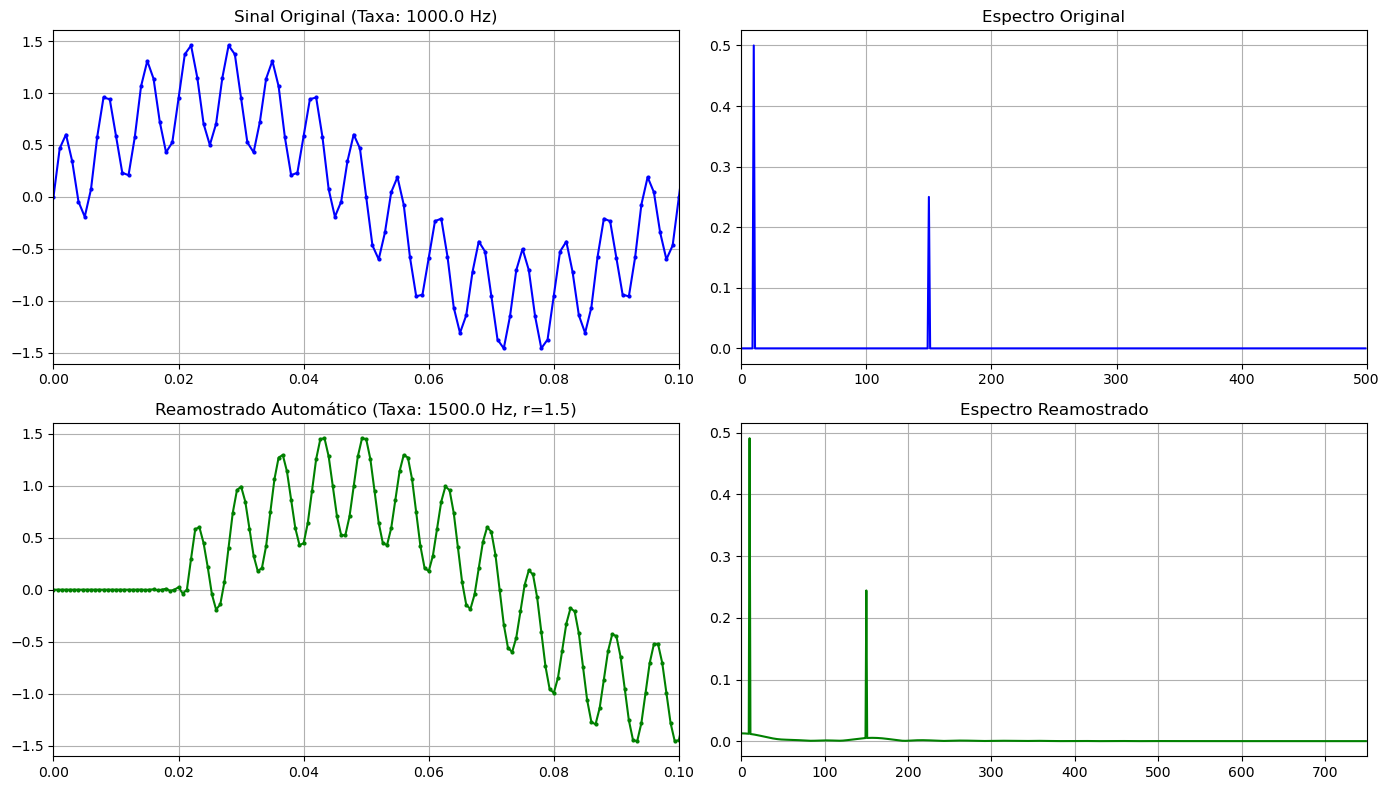

In [14]:
fs_orig = 1000.0
t_orig = np.arange(0, 1.0, 1/fs_orig)
x = np.sin(2 * np.pi * 10 * t_orig) + 0.5 * np.sin(2 * np.pi * 150 * t_orig)

# Aplicando a sua função! Tudo acontece aqui, de forma transparente.
r_fator = 1.5
y_resampled = resample_fft(x, r=r_fator, P=65, N_fft_in=128, N_fft_out=384)

# Gerando eixos de tempo e frequência para o novo sinal
fs_new = fs_orig * r_fator
t_resampled = np.arange(0, len(y_resampled)) / fs_new

# ==========================================
# 4. Geração dos Gráficos (Matriz 2x2)
# ==========================================
# Espectros
X_f = np.abs(np.fft.fft(x)) / len(x)
freqs_orig = np.fft.fftfreq(len(x), 1/fs_orig)
pos_idx_orig = freqs_orig >= 0

Y_f = np.abs(np.fft.fft(y_resampled)) / len(y_resampled)
freqs_new = np.fft.fftfreq(len(y_resampled), 1/fs_new)
pos_idx_new = freqs_new >= 0

fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# Original no Tempo
axs[0, 0].plot(t_orig, x, 'b.-', markersize=4)
axs[0, 0].set_title(f'Sinal Original (Taxa: {fs_orig} Hz)')
axs[0, 0].set_xlim(0, 0.1)
axs[0, 0].grid(True)

# Original na Frequência
axs[0, 1].plot(freqs_orig[pos_idx_orig], X_f[pos_idx_orig], 'b')
axs[0, 1].set_title('Espectro Original')
axs[0, 1].set_xlim(0, fs_orig/2)
axs[0, 1].grid(True)

# Reamostrado no Tempo
axs[1, 0].plot(t_resampled, y_resampled, 'g.-', markersize=4)
axs[1, 0].set_title(f'Reamostrado Automático (Taxa: {fs_new} Hz, r={r_fator})')
axs[1, 0].set_xlim(0, 0.1)
axs[1, 0].grid(True)

# Reamostrado na Frequência
axs[1, 1].plot(freqs_new[pos_idx_new], Y_f[pos_idx_new], 'g')
axs[1, 1].set_title('Espectro Reamostrado')
axs[1, 1].set_xlim(0, fs_new/2)
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()